In [1]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
rgc = sc.read_h5ad('data/snRNA_data/RGC.h5ad')

In [3]:
sc.tl.leiden(rgc,resolution=1.5,flavor='igraph',n_iterations=2)

In [4]:
ct_matrix = pd.crosstab(rgc.obs['leiden'], rgc.obs['C_scANVI'])
ct_norm = ct_matrix.div(ct_matrix.sum(axis=1), axis=0)
ct_norm.index = [f"C{i}" for i in ct_norm.index]
new_order = ct_norm.idxmax(axis=1).sort_values().index
ct_norm_sorted = ct_norm.loc[new_order]

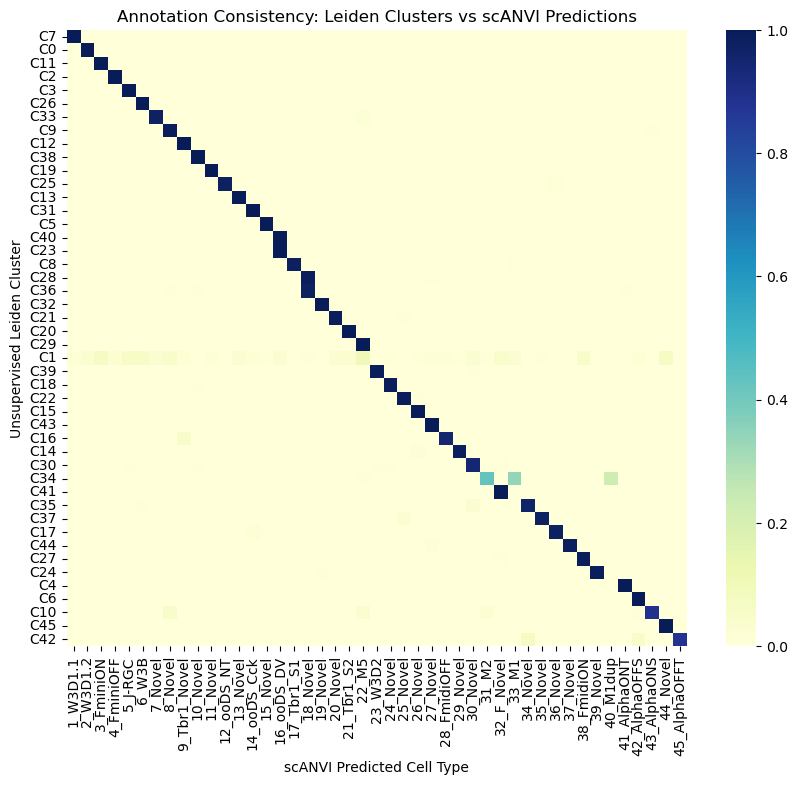

In [5]:
with plt.rc_context({"figure.figsize": (10, 8)}):
    sns.heatmap(ct_norm_sorted, annot=False, fmt=".2f", cmap='YlGnBu', yticklabels=True, xticklabels=True)
    plt.yticks(rotation=0)
    plt.title("Annotation Consistency: Leiden Clusters vs scANVI Predictions")
    plt.xlabel("scANVI Predicted Cell Type")
    plt.ylabel("Unsupervised Leiden Cluster")
    plt.show()